# Tutorial on AI-Based Voltage Estimation | <font color=red>Part 1</font>: Neural Network-Based LV Voltage Estimation


## 1. Introduction

### Objectives

The objectives of this tutorial are:

1. To familiarise learners with the process by which power engineers can estimate the voltage magnitudes of customers in a low-voltage (LV) distribution network using smart-meter active and reactive power measurements. To achieve this, you will train a neural network that maps the P/Q measurements of all customers to their voltage magnitudes.

2. To familiarise learners with the main tools and good practices used in an AI-based voltage-estimation study. You will inspect chronological data, prevent information leakage during normalisation, train a multilayer perceptron, perform blocked K-fold hyperparameter selection, select a final random seed and evaluate the model on a held-out test period.

### Structure of this Notebook

The rest of this notebook is divided into three parts:

- **2. Tutorial.**
    - You will learn, step by step, how to prepare the LV smart-meter dataset and visualise the available P, Q and V measurements.
    - You will define the neural-network and training functions before using them in the complete model-development workflow.
    - You will train a baseline model, perform blocked K-fold hyperparameter selection, select the final model and analyse its test results.
- **3. Exercises.** Here you will modify selected parts of the workflow and interpret how modelling choices affect voltage-estimation accuracy.
- **4. Simulation Workspace.** Here you can place all code relevant to the exercises and run it together.

<font color='red'>**<u>Note</u>:**</font> Make sure you understand the fixed outer train/test split, the blocked validation folds and where each MinMax scaler is fitted. Using information from the held-out test period during model development will produce an unfair estimate of performance.


## 2. Tutorial

### 2.1 Test LV Circuit and Considerations

The test LV circuit used in this tutorial is a realistic three-phase unbalanced residential feeder representative of networks in Victoria, Australia. It contains 31 single-phase customers connected across the three phases. The active power, reactive power and voltage values are synthetic smart-meter-style measurements generated for this fixed feeder at five-minute intervals.

- The feeder contains **31 single-phase customers**: 11 customers are connected to Phase 1, 10 to Phase 2 and 10 to Phase 3.
- At each time instance, the available data contain the **active power (P)**, **reactive power (Q)** and **voltage magnitude (V)** of every customer.
- The neural-network input contains 62 values—one P and one Q value for each customer—and the output contains 31 customer voltage magnitudes.
- Historical voltage measurements are training targets. After training, only a new set of customer P and Q values is required to estimate voltage.
- Line impedances, connectivity and phase labels are not explicit neural-network inputs. Their effects are represented implicitly by the training data.
- Customer ordering, phase allocation and feeder topology are fixed. A changed network requires new data and model validation.
- Upstream MV voltage variation is outside Part 1 and will be investigated separately.

Model-free does not mean physics-free: the model does not receive an explicit electrical network model, but the physical behaviour of the fixed feeder is encoded in the training examples.


<img style="float: middle;" src="LVnetwork-topology.png" width="60%">


**<center>Figure 1. Test LV Circuit Topology</center>**


| Customers (1-ph) | Phase allocation | Data resolution | NN inputs | NN outputs | Upstream MV input |
| :---: | :---: | :---: | :---: | :---: | :---: |
| 31 | 11 / 10 / 10 | 5 minutes | 62 P/Q values | 31 voltage magnitudes | Not used in Part 1 |


**<center>Table 1. Summary of the Test LV Voltage-Estimation Problem</center>**


### 2.2 Initialisation

#### 2.2.1 Import libraries

Run the code below to import the libraries used throughout this tutorial.


In [1]:
from dataclasses import dataclass
from pathlib import Path
import itertools
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 12)


#### 2.2.2 Set the working path

The working path is the folder from which Jupyter was started. The notebook uses it to locate the data, topology figure and saved K-fold results.


In [2]:
WORKING_DIRECTORY = Path.cwd()
print(f"Working directory: {WORKING_DIRECTORY.resolve()}")


Working directory: repository root


#### 2.2.3 Set reproducibility and computation device

A fixed random seed makes the initial weights and mini-batch order reproducible. PyTorch uses a GPU when available and otherwise runs on the CPU.


In [3]:
SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Computation device: {DEVICE}")


PyTorch version: 2.13.0+cpu
Computation device: cpu


### 2.3 LV Smart-Meter Dataset

#### 2.3.1 Import the training and test data

The dataset is supplied as four pickle files. `training/PQ.pkl` and `training/V.pkl` form the model-development window; `test/PQ.pkl` and `test/V.pkl` form the final held-out window. The outer split is already defined by these files and is not created by K-fold validation.


In [4]:
DATASET_NAME = "synthentic_data_5_min_LV"

# Support the proposed repository layout and a notebook-local data folder.
data_candidates = [
    WORKING_DIRECTORY / "data" / DATASET_NAME,
    WORKING_DIRECTORY / DATASET_NAME,
    WORKING_DIRECTORY.parent / "data" / DATASET_NAME,
]
DATA_DIRECTORY = next(
    (path for path in data_candidates if path.is_dir()),
    data_candidates[0],
)

TRAIN_DIRECTORY = DATA_DIRECTORY / "training"
TEST_DIRECTORY = DATA_DIRECTORY / "test"
DATA_FILES = {
    "PQ_tr": TRAIN_DIRECTORY / "PQ.pkl",
    "V_tr": TRAIN_DIRECTORY / "V.pkl",
    "PQ_te": TEST_DIRECTORY / "PQ.pkl",
    "V_te": TEST_DIRECTORY / "V.pkl",
}

missing_files = [path for path in DATA_FILES.values() if not path.is_file()]
if missing_files:
    missing_list = "\n".join(f"  - {path}" for path in missing_files)
    raise FileNotFoundError(
        "The LV dataset could not be found. Expected the following files:\n"
        f"{missing_list}\n"
        "Place the approved data package in one of the documented locations "
        "before continuing."
    )


def load_df_raw(path):
    """Load a pickle file without changing its original values or dtypes."""
    df = pd.read_pickle(path)
    return df if isinstance(df, pd.DataFrame) else pd.DataFrame(df)


PQ_tr_df_raw = load_df_raw(DATA_FILES["PQ_tr"])
V_tr_df_raw = load_df_raw(DATA_FILES["V_tr"])
PQ_te_df_raw = load_df_raw(DATA_FILES["PQ_te"])
V_te_df_raw = load_df_raw(DATA_FILES["V_te"])

print(f"Dataset directory: {DATA_DIRECTORY.resolve()}")
print("The four dataset files were loaded successfully.")

Dataset directory: synthentic_data_5_min_LV
The four dataset files were loaded successfully.


#### 2.3.2 Store and inspect the shape of the data

Each P/Q row has 62 interleaved values `[P1, Q1, P2, Q2, ...]`. Each voltage row has 31 values. The expected outer split is 6,048 training instances and 2,016 test instances.


In [5]:
dataset_summary = pd.DataFrame(
    {
        "dataset": ["PQ_tr", "V_tr", "PQ_te", "V_te"],
        "rows": [
            PQ_tr_df_raw.shape[0],
            V_tr_df_raw.shape[0],
            PQ_te_df_raw.shape[0],
            V_te_df_raw.shape[0],
        ],
        "columns": [
            PQ_tr_df_raw.shape[1],
            V_tr_df_raw.shape[1],
            PQ_te_df_raw.shape[1],
            V_te_df_raw.shape[1],
        ],
        "first dtype": [
            str(PQ_tr_df_raw.dtypes.iloc[0]),
            str(V_tr_df_raw.dtypes.iloc[0]),
            str(PQ_te_df_raw.dtypes.iloc[0]),
            str(V_te_df_raw.dtypes.iloc[0]),
        ],
    }
)

display(dataset_summary)

assert len(PQ_tr_df_raw) == len(V_tr_df_raw), (
    "Training P/Q and voltage tables must contain the same number of rows."
)
assert len(PQ_te_df_raw) == len(V_te_df_raw), (
    "Test P/Q and voltage tables must contain the same number of rows."
)
assert PQ_tr_df_raw.shape[1] == PQ_te_df_raw.shape[1] == 62
assert V_tr_df_raw.shape[1] == V_te_df_raw.shape[1] == 31

print(f"Raw PQ_train: {PQ_tr_df_raw.shape}")
print(f"Raw V_train : {V_tr_df_raw.shape}")
print(f"Raw PQ_test : {PQ_te_df_raw.shape}")
print(f"Raw V_test  : {V_te_df_raw.shape}")

print("\nPreview of the first four customer P/Q pairs:")
display(PQ_tr_df_raw.iloc[:5, :8])

print("Preview of the first eight customer voltages:")
display(V_tr_df_raw.iloc[:5, :8])

,dataset,rows,columns,first dtype
0,PQ_tr,6048,62,object
1,V_tr,6048,31,object
2,PQ_te,2016,62,object
3,V_te,2016,31,object


Raw PQ_train: (6048, 62)
Raw V_train : (6048, 31)
Raw PQ_test : (2016, 62)
Raw V_test  : (2016, 31)

Preview of the first four customer P/Q pairs:


,0,1,2,3,4,5,6,7
0,0.120693,0.032818,0.649865,-0.296134,0.349897,0.169386,0.335303,0.051972
1,0.117263,0.028463,0.320885,0.139661,0.215703,0.038703,0.590841,0.254373
2,0.116715,-0.047785,0.822305,0.278458,0.354829,-0.133146,0.882382,-0.27772
3,0.107176,-0.01041,0.990251,-0.436451,0.25331,0.075004,0.230393,-0.026619
4,0.138526,0.01292,1.071487,-0.447064,0.237154,0.051309,0.640064,0.120067


Preview of the first eight customer voltages:


,0,1,2,3,4,5,6,7
0,249.821308,249.888347,249.892601,249.717129,249.83258,249.881812,249.636639,249.76791
1,249.899409,249.843989,249.866556,249.821587,249.771007,249.826385,249.794231,249.713772
2,249.93567,249.821681,249.89114,249.834439,249.801263,249.859837,249.820937,249.751415
3,249.896948,249.884214,249.874603,249.835795,249.858882,249.840205,249.793206,249.802437
4,249.798935,249.826984,249.938723,249.676499,249.803004,249.920977,249.597586,249.742323


#### 2.3.3 Convert the data and check the P/Q/V interface

The raw tables are converted to `float32`, checked for missing or non-finite values and separated into P and Q arrays for validation. This step confirms the required `62 inputs → 31 outputs` interface before modelling.


In [6]:
def to_numeric_df(df):
    """Convert every column to a numerical dtype."""
    return df.apply(pd.to_numeric, errors="coerce")


PQ_tr_df = to_numeric_df(PQ_tr_df_raw)
V_tr_df = to_numeric_df(V_tr_df_raw)
PQ_te_df = to_numeric_df(PQ_te_df_raw)
V_te_df = to_numeric_df(V_te_df_raw)

PQ_tr = PQ_tr_df.to_numpy(np.float32)
V_tr = V_tr_df.to_numpy(np.float32)
PQ_te = PQ_te_df.to_numpy(np.float32)
V_te = V_te_df.to_numpy(np.float32)

invalid_summary = {
    "PQ_tr": int((~np.isfinite(PQ_tr)).sum()),
    "V_tr": int((~np.isfinite(V_tr)).sum()),
    "PQ_te": int((~np.isfinite(PQ_te)).sum()),
    "V_te": int((~np.isfinite(V_te)).sum()),
}
print("Invalid-value summary:", invalid_summary)
if any(count > 0 for count in invalid_summary.values()):
    raise ValueError(
        "Missing or non-finite values were found after numerical conversion."
    )

# Recover P and Q from P|Q = [P1, Q1, P2, Q2, ...].
P_tr, Q_tr = PQ_tr[:, 0::2], PQ_tr[:, 1::2]
P_te, Q_te = PQ_te[:, 0::2], PQ_te[:, 1::2]

C = P_tr.shape[1]
assert Q_tr.shape[1] == C and V_tr.shape[1] == C, (
    "|C| mismatch among P, Q and V in the training period."
)
assert Q_te.shape[1] == C and V_te.shape[1] == C, (
    "|C| mismatch among P, Q and V in the test period."
)
assert PQ_tr.shape[1] == 2 * C and PQ_te.shape[1] == 2 * C

print(f"|C|={C}, |T_train|={P_tr.shape[0]}, |T_test|={P_te.shape[0]}")
print(
    "Shapes -> P_tr", P_tr.shape,
    "Q_tr", Q_tr.shape,
    "V_tr", V_tr.shape,
    "P|Q_tr", PQ_tr.shape,
)

Invalid-value summary: {'PQ_tr': 0, 'V_tr': 0, 'PQ_te': 0, 'V_te': 0}
|C|=31, |T_train|=6048, |T_test|=2016
Shapes -> P_tr (6048, 31) Q_tr (6048, 31) V_tr (6048, 31) P|Q_tr (6048, 62)


#### 2.3.4 Visualise customer P and Q profiles

The following plot shows one day (288 five-minute instances) for three representative customers. P and Q are plotted separately so their scale and temporal variation can be inspected before normalisation.


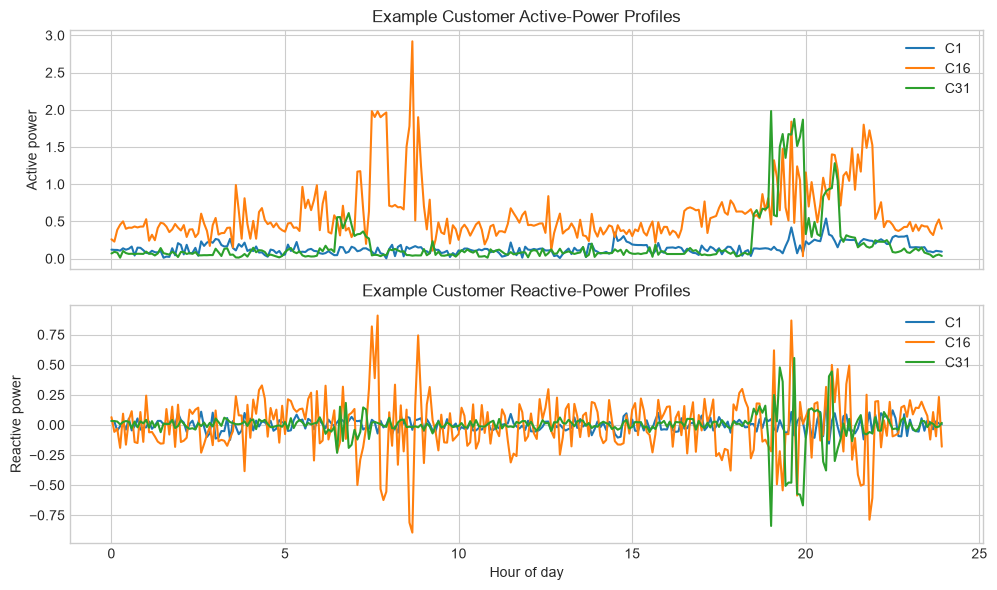

In [7]:
instances_per_day = 24 * 60 // 5
selected_customers = [0, C // 2, C - 1]
time_hours = np.arange(instances_per_day) * 5 / 60

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for customer in selected_customers:
    axes[0].plot(
        time_hours,
        P_tr[:instances_per_day, customer],
        label=f"C{customer + 1}",
    )
    axes[1].plot(
        time_hours,
        Q_tr[:instances_per_day, customer],
        label=f"C{customer + 1}",
    )

axes[0].set_ylabel("Active power")
axes[0].set_title("Example Customer Active-Power Profiles")
axes[1].set_ylabel("Reactive power")
axes[1].set_xlabel("Hour of day")
axes[1].set_title("Example Customer Reactive-Power Profiles")
for axis in axes:
    axis.legend(loc="best")
fig.tight_layout()
plt.show()


#### 2.3.5 Visualise customer voltage profiles

The same customers are shown below using their voltage targets. These targets are available during offline training but are not neural-network inputs during inference.


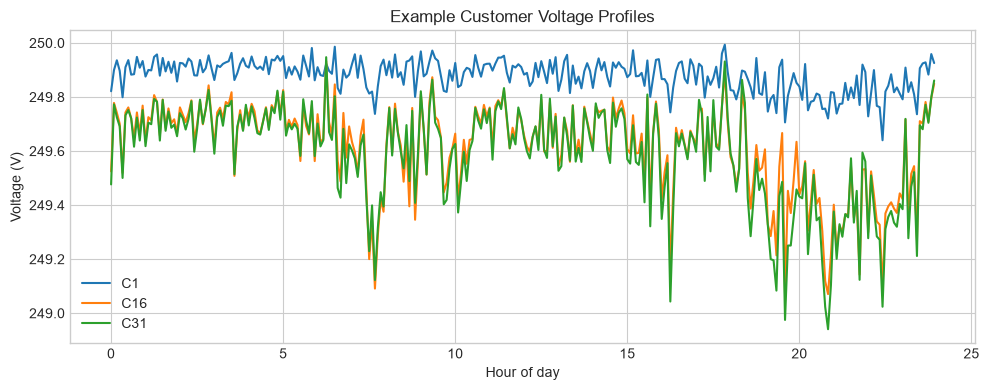

In [8]:
plt.figure(figsize=(10, 4))
for customer in selected_customers:
    plt.plot(
        time_hours,
        V_tr[:instances_per_day, customer],
        label=f"C{customer + 1}",
    )
plt.xlabel("Hour of day")
plt.ylabel("Voltage (V)")
plt.title("Example Customer Voltage Profiles")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


#### 2.3.6 Create a blocked diagnostic split and normalise the data

For the baseline demonstration, the 6,048-instance training window is divided into three consecutive blocks. One 2,016-instance block is used for validation and the other two blocks are used for training. The independent 2,016-instance test window remains unused.

The MinMax scalers are fitted only on the baseline training blocks and then applied to validation. Validation values can fall below 0 or above 1 when they extend beyond the training range. Section 2.5.2 repeats the same leakage-safe procedure across all three blocked folds.


In [9]:
BASELINE_KFOLDS = 3
baseline_fold_sizes = [len(PQ_tr) // BASELINE_KFOLDS] * BASELINE_KFOLDS
for i in range(len(PQ_tr) % BASELINE_KFOLDS):
    baseline_fold_sizes[i] += 1

# Use the first continuous block for diagnosis, matching new.ipynb.
validation_start = 0
validation_end = baseline_fold_sizes[0]
Xv_raw = PQ_tr[validation_start:validation_end]
Yv_raw = V_tr[validation_start:validation_end]
Xtr_raw = np.concatenate(
    [PQ_tr[:validation_start], PQ_tr[validation_end:]],
    axis=0,
)
Ytr_raw = np.concatenate(
    [V_tr[:validation_start], V_tr[validation_end:]],
    axis=0,
)

# Fit only on the baseline training portion.
xs = MinMaxScaler().fit(Xtr_raw)
ys = MinMaxScaler().fit(Ytr_raw)

Xtr = xs.transform(Xtr_raw).astype(np.float32)
Ytr = ys.transform(Ytr_raw).astype(np.float32)
Xv = xs.transform(Xv_raw).astype(np.float32)
Yv = ys.transform(Yv_raw).astype(np.float32)
Xte = xs.transform(PQ_te).astype(np.float32)

split_summary = pd.DataFrame(
    {
        "matrix": ["Xtr / Ytr", "Xv / Yv", "PQ_te / V_te"],
        "instances": [len(Xtr), len(Xv), len(PQ_te)],
        "role": ["Two baseline training blocks", "One blocked validation fold", "Final test only"],
        "used to fit xs and ys": ["Yes", "No", "No"],
    }
)
display(split_summary)

range_summary = pd.DataFrame(
    {
        "matrix": ["Xtr", "Ytr", "Xv", "Yv"],
        "minimum": [Xtr.min(), Ytr.min(), Xv.min(), Yv.min()],
        "maximum": [Xtr.max(), Ytr.max(), Xv.max(), Yv.max()],
    }
)
display(range_summary.round(4))

print("V_te has not been used or transformed.")

,matrix,instances,role,used to fit xs and ys
0,Xtr / Ytr,4032,Two baseline training blocks,Yes
1,Xv / Yv,2016,One blocked validation fold,No
2,PQ_te / V_te,2016,Final test only,No


,matrix,minimum,maximum
0,Xtr,0.0000,1.0000
1,Ytr,0.0000,1.0000
2,Xv,-0.3668,2.2272
3,Yv,-0.5775,1.0850


V_te has not been used or transformed.


### 2.4 Definition of Functions

#### 2.4.1 `NNi`: define the multilayer perceptron

`NNi` creates a configurable multilayer perceptron. For this problem, the input layer receives 62 P/Q values and the linear output layer returns 31 voltage estimates. Hidden layers use a nonlinear activation function. All linear weights use Glorot Uniform initialisation and all biases start at zero.


In [10]:
class NNi(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dims=(128,), activation="tanh"):
        super().__init__()

        acts = {
            "tanh": nn.Tanh,
            "relu": nn.ReLU,
            "sigmoid": nn.Sigmoid,
            "selu": nn.SELU,
            "leaky_relu": nn.LeakyReLU,
            "swish": nn.SiLU,
        }
        if activation not in acts:
            available = ", ".join(acts)
            raise ValueError(
                f"Unknown activation '{activation}'. Choose from: {available}."
            )

        dims = [in_dim] + list(hidden_dims)
        layers = []
        for i in range(len(hidden_dims)):
            layers += [nn.Linear(dims[i], dims[i + 1]), acts[activation]()]

        self.backbone = nn.Sequential(*layers)
        self.out = nn.Linear(hidden_dims[-1], out_dim)

        # Start with balanced random weights and zero biases.
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.out(self.backbone(x))

#### 2.4.2 `predict_unscaled`: return voltage estimates in volts

The neural network is trained on normalised voltage. This helper performs inference and applies the fitted output scaler so errors can be reported in volts.


In [11]:
def predict_unscaled(model, X_scaled, output_scaler):
    # Estimate voltages and return them in the original voltage scale.
    model.eval()
    with torch.no_grad():
        V_scaled = model(
            torch.from_numpy(X_scaled).to(DEVICE)
        ).cpu().numpy()
    return output_scaler.inverse_transform(V_scaled)


#### 2.4.3 `train_mbgo_adam`: train a diagnostic model

This function performs mini-batch gradient optimisation using MSE, backpropagation and Adam. It monitors a validation block, stops early when validation loss no longer improves and restores the best parameter state. It is used only for the short baseline diagnostic.


In [12]:
@dataclass
class TrainResult:
    model: nn.Module
    train_losses: list
    val_losses: list
    best_epoch: int
    best_val: float


def train_mbgo_adam(
    model,
    Xtr,
    Ytr,
    Xv,
    Yv,
    lr=1e-3,
    wd=1e-5,
    batch=72,
    epochs=200,
    patience=25,
):
    """Train an NN with mini-batches, Adam and early stopping."""
    training_data = TensorDataset(
        torch.from_numpy(Xtr),
        torch.from_numpy(Ytr),
    )
    training_loader = DataLoader(
        training_data,
        batch_size=batch,
        shuffle=True,
    )

    Xv_tensor = torch.from_numpy(Xv).to(DEVICE)
    Yv_tensor = torch.from_numpy(Yv).to(DEVICE)
    model = model.to(DEVICE)

    loss_fn = nn.MSELoss()
    optimiser = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=wd,
    )

    train_losses = []
    val_losses = []
    best_val = float("inf")
    best_epoch = 0
    best_state = {
        name: value.detach().clone()
        for name, value in model.state_dict().items()
    }
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_instances = 0

        for X_batch, Y_batch in training_loader:
            X_batch = X_batch.to(DEVICE)
            Y_batch = Y_batch.to(DEVICE)

            optimiser.zero_grad()
            V_estimated = model(X_batch)
            loss = loss_fn(V_estimated, Y_batch)
            loss.backward()
            optimiser.step()

            total_loss += loss.item() * X_batch.size(0)
            total_instances += X_batch.size(0)

        train_loss = total_loss / total_instances

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv_tensor), Yv_tensor).item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_epoch = epoch
            best_state = {
                name: value.detach().clone()
                for name, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)
    return TrainResult(
        model=model,
        train_losses=train_losses,
        val_losses=val_losses,
        best_epoch=best_epoch,
        best_val=best_val,
    )

#### 2.4.4 K-fold and fixed-epoch training functions

The formal hyperparameter search follows the strict workflow in `new.ipynb`: each validation fold is one continuous time block, each fold fits its own scalers, every candidate trains for its specified fixed number of epochs and the test period is never used. `run_grid_search` evaluates every combination and ranks them by mean blocked K-fold RMSE.


In [13]:
import itertools
import time

KFOLDS = 3
RUN_FULL_SEARCH = False

SEARCH_SPACE = {
    "hidden_multiplier": [3, 5],
    "activation": ["tanh"],
    "lr": [1e-3, 1e-4],
    "weight_decay": [1e-4, 1e-5],
    "batch_size": [72],
    "epochs": [1000, 2000],
}


def blocked_kfold_indices(n_instances, k=3):
    """Return k consecutive validation blocks and their training indices."""
    fold_sizes = [n_instances // k] * k
    for i in range(n_instances % k):
        fold_sizes[i] += 1

    all_indices = np.arange(n_instances)
    folds = []
    start = 0

    for fold_size in fold_sizes:
        end = start + fold_size
        validation_indices = all_indices[start:end]
        training_indices = np.concatenate(
            [all_indices[:start], all_indices[end:]]
        )
        folds.append((training_indices, validation_indices))
        start = end

    return folds


def train_fixed(model, Xtr, Ytr, lr, wd, batch, epochs):
    """Train for a fixed number of epochs without early stopping."""
    dataset = TensorDataset(
        torch.from_numpy(Xtr),
        torch.from_numpy(Ytr),
    )
    loader = DataLoader(dataset, batch_size=batch, shuffle=True)
    model = model.to(DEVICE)
    optimiser = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=wd,
    )
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            Y_batch = Y_batch.to(DEVICE)

            optimiser.zero_grad()
            loss = loss_fn(model(X_batch), Y_batch)
            loss.backward()
            optimiser.step()

    return model


def evaluate_config(config, PQ, V, C, k=KFOLDS):
    """Return blocked k-fold RMSE for one hyperparameter configuration."""
    hidden_neurons = round(config["hidden_multiplier"] * C)
    fold_rmse = []
    start_time = time.time()

    for training_indices, validation_indices in blocked_kfold_indices(len(PQ), k):
        PQ_fold_train = PQ[training_indices]
        V_fold_train = V[training_indices]
        PQ_fold_val = PQ[validation_indices]
        V_fold_val = V[validation_indices]

        xs_fold = MinMaxScaler().fit(PQ_fold_train)
        ys_fold = MinMaxScaler().fit(V_fold_train)

        Xt = xs_fold.transform(PQ_fold_train).astype(np.float32)
        Yt = ys_fold.transform(V_fold_train).astype(np.float32)
        Xv_fold = xs_fold.transform(PQ_fold_val).astype(np.float32)

        set_seed(SEED)
        model = NNi(
            in_dim=Xt.shape[1],
            out_dim=Yt.shape[1],
            hidden_dims=(hidden_neurons,),
            activation=config["activation"],
        )
        model = train_fixed(
            model,
            Xt,
            Yt,
            lr=config["lr"],
            wd=config["weight_decay"],
            batch=config["batch_size"],
            epochs=config["epochs"],
        )

        V_fold_estimated = predict_unscaled(model, Xv_fold, ys_fold)
        fold_rmse.append(
            float(np.sqrt(np.mean((V_fold_val - V_fold_estimated) ** 2)))
        )

    return {
        "hidden_neurons": hidden_neurons,
        "RMSE_kfold": float(np.mean(fold_rmse)),
        "RMSE_std": float(np.std(fold_rmse)),
        "train_time_s": float(time.time() - start_time),
    }


def run_grid_search(PQ, V, C, search_space=SEARCH_SPACE):
    """Evaluate every combination and return the configurations ranked by RMSE."""
    configurations = [
        dict(zip(search_space, values))
        for values in itertools.product(*search_space.values())
    ]
    rows = []

    for number, config in enumerate(configurations, start=1):
        scores = evaluate_config(config, PQ, V, C)
        rows.append({**config, **scores})
        print(
            f"Configuration {number:>2}/{len(configurations)}: "
            f"RMSE={scores['RMSE_kfold']:.6f}"
        )

    return (
        pd.DataFrame(rows)
        .sort_values("RMSE_kfold")
        .reset_index(drop=True)
    )

### 2.5 Model Training and Selection

#### 2.5.1 Train a baseline model

The baseline uses `62 → 93 → 31`, `tanh`, Adam, a batch size of 72 (six hours of five-minute samples) and early stopping. This run demonstrates how learning and validation curves behave; it does not select the final hyperparameters.


In [14]:
BASELINE_HIDDEN = 3 * C
BASELINE_ACT = "tanh"

set_seed(SEED)
nni = NNi(
    in_dim=Xtr.shape[1],
    out_dim=Ytr.shape[1],
    hidden_dims=(BASELINE_HIDDEN,),
    activation=BASELINE_ACT,
).to(DEVICE)

trainable_parameters = sum(
    parameter.numel()
    for parameter in nni.parameters()
    if parameter.requires_grad
)

architecture_summary = pd.DataFrame(
    {
        "layer": ["Input", "Hidden", "Output"],
        "dimension": [2 * C, BASELINE_HIDDEN, C],
        "operation": [
            "P|Q",
            f"Linear + {BASELINE_ACT}",
            "Linear V estimate",
        ],
    }
)

display(architecture_summary)
print(nni)
print(f"Trainable parameters: {trainable_parameters:,}")

# Check 2|C| -> |C| before training.
sample_input = torch.from_numpy(Xtr[:4]).to(DEVICE)
with torch.no_grad():
    sample_output = nni(sample_input)

assert sample_output.shape == (4, C)
print(f"Interface check: {tuple(sample_input.shape)} -> {tuple(sample_output.shape)}")

,layer,dimension,operation
0,Input,62,P|Q
1,Hidden,93,Linear + tanh
2,Output,31,Linear V estimate


NNi(
  (backbone): Sequential(
    (0): Linear(in_features=62, out_features=93, bias=True)
    (1): Tanh()
  )
  (out): Linear(in_features=93, out_features=31, bias=True)
)
Trainable parameters: 8,773
Interface check: (4, 62) -> (4, 31)


In [15]:
BASELINE_LR = 1e-3
BASELINE_WD = 1e-5
BASELINE_BATCH = 72
BASELINE_EPOCHS = 140
BASELINE_PATIENCE = 25

# Recreate the model so rerunning this cell starts from the same initial state.
set_seed(SEED)
nni = NNi(
    in_dim=Xtr.shape[1],
    out_dim=Ytr.shape[1],
    hidden_dims=(BASELINE_HIDDEN,),
    activation=BASELINE_ACT,
)

baseline_result = train_mbgo_adam(
    nni,
    Xtr,
    Ytr,
    Xv,
    Yv,
    lr=BASELINE_LR,
    wd=BASELINE_WD,
    batch=BASELINE_BATCH,
    epochs=BASELINE_EPOCHS,
    patience=BASELINE_PATIENCE,
)


Vtr_estimated = predict_unscaled(baseline_result.model, Xtr, ys)
Vv_estimated = predict_unscaled(baseline_result.model, Xv, ys)

baseline_metrics = pd.DataFrame(
    {
        "period": ["Training", "Validation"],
        "RMSE (V)": [
            np.sqrt(np.mean((Ytr_raw - Vtr_estimated) ** 2)),
            np.sqrt(np.mean((Yv_raw - Vv_estimated) ** 2)),
        ],
        "MAE (V)": [
            np.mean(np.abs(Ytr_raw - Vtr_estimated)),
            np.mean(np.abs(Yv_raw - Vv_estimated)),
        ],
    }
)

display(baseline_metrics.round(6))
print(f"Epochs completed: {len(baseline_result.train_losses)}")
print(f"Best validation epoch: {baseline_result.best_epoch}")
print(f"Best scaled validation MSE: {baseline_result.best_val:.8f}")


,period,RMSE (V),MAE (V)
0,Training,0.009446,0.006526
1,Validation,0.014651,0.007937


Epochs completed: 140
Best validation epoch: 138
Best scaled validation MSE: 0.00003775


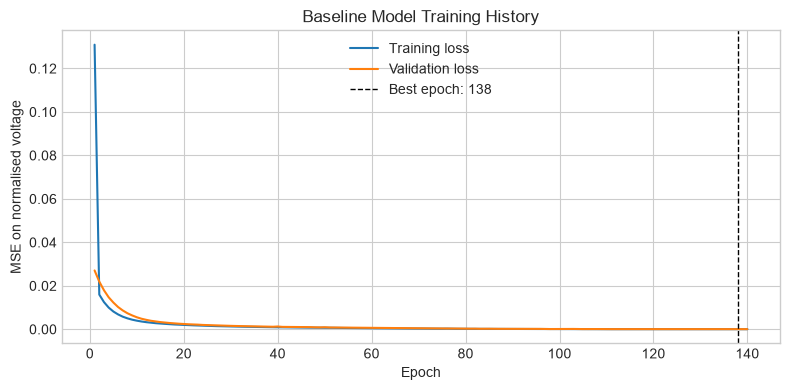

In [16]:
epochs_completed = np.arange(1, len(baseline_result.train_losses) + 1)

plt.figure(figsize=(8, 4))
plt.plot(
    epochs_completed,
    baseline_result.train_losses,
    label="Training loss",
)
plt.plot(
    epochs_completed,
    baseline_result.val_losses,
    label="Validation loss",
)
plt.axvline(
    baseline_result.best_epoch,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Best epoch: {baseline_result.best_epoch}",
)
plt.xlabel("Epoch")
plt.ylabel("MSE on normalised voltage")
plt.title("Baseline Model Training History")
plt.legend()
plt.tight_layout()
plt.show()

The training and validation losses should decrease early in training. A persistent gap can indicate overfitting. RMSE and MAE are calculated after returning predictions to volts. This baseline is diagnostic only; the formal selection process follows next.


#### 2.5.2 Blocked K-fold hyperparameter selection

The reduced search space contains 16 combinations:

| Hyperparameter | Candidate values |
|---|---|
| Hidden neurons | 93 or 155 (`3|C|` or `5|C|`) |
| Activation | `tanh` |
| Learning rate | `1e-3` or `1e-4` |
| L2 weight decay | `1e-4` or `1e-5` |
| Batch size | 72 |
| Epochs | 1,000 or 2,000 |

Every configuration is trained on three folds, producing 48 model fits. Because epochs are themselves compared, formal search candidates do not use early stopping. The included `LV_search_results.csv` is loaded by default; set `RUN_FULL_SEARCH=True` to reproduce the complete search.


In [17]:
fold_rows = []
for fold_number, (training_indices, validation_indices) in enumerate(
    blocked_kfold_indices(len(PQ_tr), KFOLDS),
    start=1,
):
    fold_rows.append(
        {
            "fold": fold_number,
            "training instances": len(training_indices),
            "validation instances": len(validation_indices),
            "validation range (1-based)": (
                f"{validation_indices[0] + 1}–{validation_indices[-1] + 1}"
            ),
        }
    )

fold_summary = pd.DataFrame(fold_rows)
print("Blocked three-fold partitions inside the 6,048-instance training window:")
display(fold_summary)

if RUN_FULL_SEARCH:
    search_results = run_grid_search(PQ_tr, V_tr, C)
    search_source = "newly calculated results"
else:
    reference_candidates = [
        WORKING_DIRECTORY / "LV_search_results.csv",
        WORKING_DIRECTORY / "reference_results" / "LV_search_results.csv",
        WORKING_DIRECTORY
        / "Part_1_LV_Voltage_Estimation"
        / "reference_results"
        / "LV_search_results.csv",
        WORKING_DIRECTORY
        / "results"
        / "hyperparameter_selection"
        / "LV_search_results.csv",
    ]
    reference_path = next(
        (path for path in reference_candidates if path.is_file()),
        None,
    )
    if reference_path is None:
        raise FileNotFoundError(
            "LV_search_results.csv was not found. Add the reference-results "
            "folder or set RUN_FULL_SEARCH=True."
        )

    search_results = pd.read_csv(reference_path)
    search_source = f"saved reference results: {reference_path.resolve()}"

search_results = (
    search_results
    .sort_values("RMSE_kfold")
    .reset_index(drop=True)
)

columns_to_show = [
    "hidden_neurons",
    "activation",
    "lr",
    "weight_decay",
    "batch_size",
    "epochs",
    "RMSE_kfold",
    "RMSE_std",
]

print(f"Using {search_source}")
print("Complete ranking of all 16 hyperparameter configurations:")
display(search_results[columns_to_show].round(6))

best_row = search_results.iloc[0]
best_config = {
    "hidden_neurons": int(best_row["hidden_neurons"]),
    "activation": str(best_row["activation"]),
    "lr": float(best_row["lr"]),
    "weight_decay": float(best_row["weight_decay"]),
    "batch_size": int(best_row["batch_size"]),
    "epochs": int(best_row["epochs"]),
}

print("Selected hyperparameters:")
for name, value in best_config.items():
    print(f"  {name}: {value}")
print(f"Mean cross-validation RMSE: {best_row['RMSE_kfold']:.6f} V")


Blocked three-fold partitions inside the 6,048-instance training window:


,fold,training instances,validation instances,validation range (1-based)
0,1,4032,2016,1–2016
1,2,4032,2016,2017–4032
2,3,4032,2016,4033–6048


Using saved reference results: LV_search_results.csv
Complete ranking of all 16 hyperparameter configurations:


,hidden_neurons,activation,lr,weight_decay,batch_size,epochs,RMSE_kfold,RMSE_std
0,155,tanh,0.0001,0.00001,72,2000,0.010986,0.000593
1,93,tanh,0.0001,0.00001,72,2000,0.011058,0.001003
2,155,tanh,0.0001,0.00001,72,1000,0.011156,0.001125
3,93,tanh,0.0010,0.00001,72,1000,0.011737,0.001098
4,93,tanh,0.0001,0.00001,72,1000,0.011823,0.001172
5,93,tanh,0.0010,0.00001,72,2000,0.012154,0.000426
6,155,tanh,0.0010,0.00001,72,2000,0.012833,0.001006
7,155,tanh,0.0010,0.00001,72,1000,0.013701,0.002051
8,155,tanh,0.0001,0.00010,72,1000,0.055268,0.001336
9,155,tanh,0.0001,0.00010,72,2000,0.055276,0.000914


Selected hyperparameters:
  hidden_neurons: 155
  activation: tanh
  lr: 0.0001
  weight_decay: 1e-05
  batch_size: 72
  epochs: 2000
Mean cross-validation RMSE: 0.010986 V


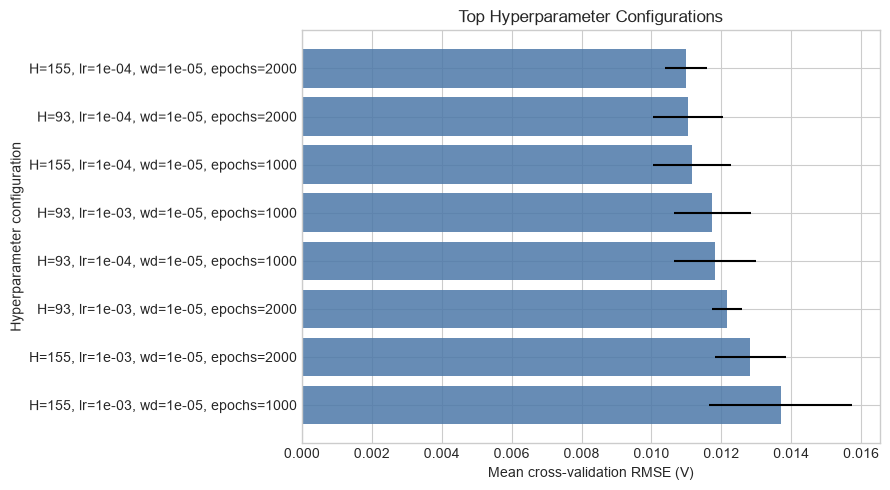

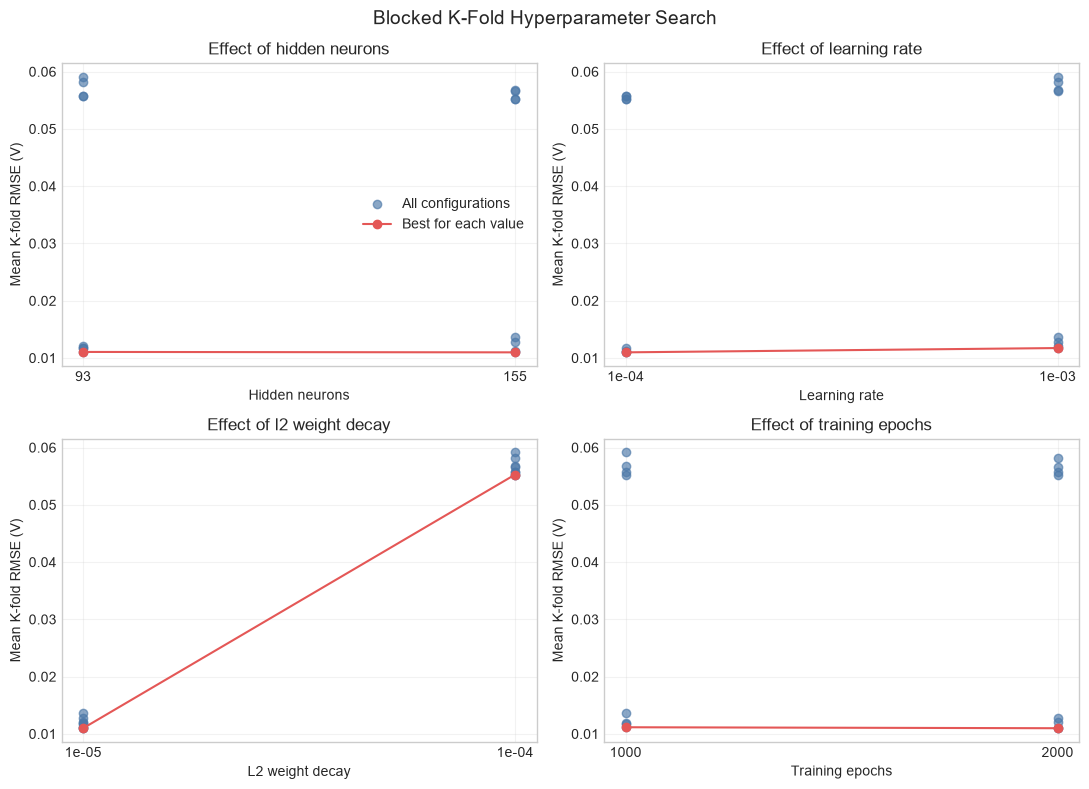

In [18]:
top_results = search_results.head(8).copy()
top_results["label"] = top_results.apply(
    lambda row: (
        f"H={int(row['hidden_neurons'])}, "
        f"lr={row['lr']:.0e}, wd={row['weight_decay']:.0e}, "
        f"epochs={int(row['epochs'])}"
    ),
    axis=1,
)
top_results = top_results.iloc[::-1]

plt.figure(figsize=(9, 5))
plt.barh(
    top_results["label"],
    top_results["RMSE_kfold"],
    xerr=top_results["RMSE_std"],
    color="#4C78A8",
    alpha=0.85,
)
plt.xlabel("Mean cross-validation RMSE (V)")
plt.ylabel("Hyperparameter configuration")
plt.title("Top Hyperparameter Configurations")
plt.tight_layout()
plt.show()

parameter_panels = [
    ("hidden_neurons", "Hidden neurons"),
    ("lr", "Learning rate"),
    ("weight_decay", "L2 weight decay"),
    ("epochs", "Training epochs"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for axis, (parameter, label) in zip(axes.ravel(), parameter_panels):
    values = sorted(search_results[parameter].unique())
    positions = {value: index for index, value in enumerate(values)}
    x_values = search_results[parameter].map(positions).to_numpy(float)
    best_per_value = (
        search_results.groupby(parameter)["RMSE_kfold"].min().reindex(values)
    )

    axis.scatter(
        x_values,
        search_results["RMSE_kfold"],
        alpha=0.65,
        color="#4C78A8",
        label="All configurations",
    )
    axis.plot(
        range(len(values)),
        best_per_value.to_numpy(),
        "o-",
        color="#E45756",
        label="Best for each value",
    )

    tick_labels = [
        f"{value:.0e}" if parameter in {"lr", "weight_decay"}
        else str(int(value))
        for value in values
    ]
    axis.set_xticks(range(len(values)), tick_labels)
    axis.set_xlabel(label)
    axis.set_ylabel("Mean K-fold RMSE (V)")
    axis.set_title(f"Effect of {label.lower()}")
    axis.grid(alpha=0.25)

axes[0, 0].legend(loc="best")
fig.suptitle("Blocked K-Fold Hyperparameter Search", fontsize=14)
fig.tight_layout()
plt.show()

`RMSE_kfold` is the average validation RMSE in volts and `RMSE_std` measures variation across the three folds. The first row is selected because it has the lowest mean RMSE. The four parameter panels show all configurations and the best result achieved at each candidate value.


#### 2.5.3 Train multiple seeds and select the final model

After fixing the hyperparameters, new input and output scalers are fitted on the complete 6,048-instance training window. Ten networks are trained from different random seeds and the network with the lowest training RMSE is retained. Test voltages are not used to select the seed.

The included `LV_final_seed_results.csv` stores the completed ten-seed ranking. By default, the notebook reads this ranking and retrains only the selected seed. Set `RUN_MULTI_SEED_TRAINING=True` to reproduce all ten runs.


In [19]:
SEEDS_FINAL = list(range(10))
RUN_MULTI_SEED_TRAINING = False

# Refit normalisation using the complete training period only.
xs_full = MinMaxScaler().fit(PQ_tr)
ys_full = MinMaxScaler().fit(V_tr)

Xtr_full = xs_full.transform(PQ_tr).astype(np.float32)
Ytr_full = ys_full.transform(V_tr).astype(np.float32)
Xte_full = xs_full.transform(PQ_te).astype(np.float32)


def train_final_seed(seed):
    """Train one final-model candidate and return its training information."""
    set_seed(seed)
    model = NNi(
        in_dim=Xtr_full.shape[1],
        out_dim=Ytr_full.shape[1],
        hidden_dims=(best_config["hidden_neurons"],),
        activation=best_config["activation"],
    )

    start_time = time.time()
    model = train_fixed(
        model,
        Xtr_full,
        Ytr_full,
        lr=best_config["lr"],
        wd=best_config["weight_decay"],
        batch=best_config["batch_size"],
        epochs=best_config["epochs"],
    )
    training_time = time.time() - start_time

    Vtr_estimated = predict_unscaled(model, Xtr_full, ys_full)
    train_rmse = float(
        np.sqrt(np.mean((V_tr - Vtr_estimated) ** 2))
    )

    result = {
        "seed": int(seed),
        "train_RMSE": train_rmse,
        "training_time_seconds": float(training_time),
    }
    return model, result

In [20]:
if RUN_MULTI_SEED_TRAINING:
    seed_rows = []
    FINAL_MODEL = None
    lowest_train_rmse = float("inf")

    for seed in SEEDS_FINAL:
        candidate_model, seed_result = train_final_seed(seed)
        seed_rows.append(seed_result)
        print(
            f"Seed {seed}: training RMSE "
            f"{seed_result['train_RMSE']:.6f}"
        )

        if seed_result["train_RMSE"] < lowest_train_rmse:
            lowest_train_rmse = seed_result["train_RMSE"]
            FINAL_MODEL = candidate_model
            selected_seed = seed

    final_seed_results = (
        pd.DataFrame(seed_rows)
        .sort_values("train_RMSE")
        .reset_index(drop=True)
    )
    seed_source = "newly trained models"
else:
    seed_reference_candidates = [
        WORKING_DIRECTORY / "LV_final_seed_results.csv",
        WORKING_DIRECTORY / "reference_results" / "LV_final_seed_results.csv",
        WORKING_DIRECTORY
        / "Part_1_LV_Voltage_Estimation"
        / "reference_results"
        / "LV_final_seed_results.csv",
        WORKING_DIRECTORY
        / "results"
        / "hyperparameter_selection"
        / "LV_final_seed_results.csv",
    ]
    seed_reference_path = next(
        (path for path in seed_reference_candidates if path.is_file()),
        None,
    )
    if seed_reference_path is None:
        raise FileNotFoundError(
            "LV_final_seed_results.csv was not found. Add the reference-results "
            "folder or set RUN_MULTI_SEED_TRAINING=True."
        )

    saved_seed_results = pd.read_csv(seed_reference_path)
    # Only training information is used for model selection.
    final_seed_results = (
        saved_seed_results[
            ["seed", "train_RMSE", "training_time_seconds"]
        ]
        .sort_values("train_RMSE")
        .reset_index(drop=True)
    )
    selected_seed = int(final_seed_results.iloc[0]["seed"])
    FINAL_MODEL, current_final_run = train_final_seed(selected_seed)
    seed_source = f"saved seed ranking: {seed_reference_path.resolve()}"

print(f"Using {seed_source}")
display(final_seed_results.round(6))
print(f"Selected seed: {selected_seed}")

if not RUN_MULTI_SEED_TRAINING:
    print(
        "Retrained selected model RMSE: "
        f"{current_final_run['train_RMSE']:.6f}"
    )


Using saved seed ranking: LV_final_seed_results.csv


,seed,train_RMSE,training_time_seconds
0,1,0.009299,137.171383
1,9,0.009312,136.519536
2,6,0.009403,136.587838
3,0,0.009420,138.022125
4,5,0.009438,136.515747
5,3,0.009459,136.484250
6,2,0.009670,137.191281
7,7,0.009768,136.649282
8,8,0.009923,136.763636
9,4,0.010060,136.392116


Selected seed: 1
Retrained selected model RMSE: 0.009299


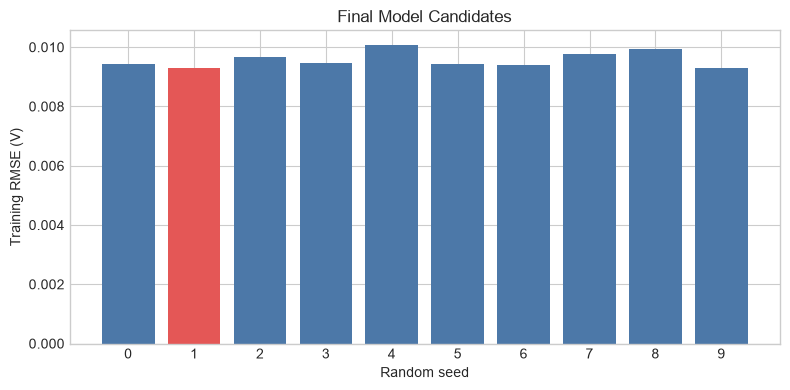

In [21]:
seed_plot_data = final_seed_results.sort_values("seed")

plt.figure(figsize=(8, 4))
plt.bar(
    seed_plot_data["seed"].astype(str),
    seed_plot_data["train_RMSE"],
    color=[
        "#E45756" if int(seed) == selected_seed else "#4C78A8"
        for seed in seed_plot_data["seed"]
    ],
)
plt.xlabel("Random seed")
plt.ylabel("Training RMSE (V)")
plt.title("Final Model Candidates")
plt.tight_layout()
plt.show()


Every candidate uses the same architecture and training settings; only the seed changes. The highlighted bar identifies the seed with the lowest training RMSE. `FINAL_MODEL`, `xs_full`, `ys_full` and `Xte_full` are retained for final evaluation.


### 2.6 Further Analysis of the Results

#### 2.6.1 Evaluate the held-out test period

Model development is now complete, so the held-out test period can be used for the first time. The selected model estimates all customer voltages, predictions are returned to volts and overall RMSE, MAE and maximum absolute error are calculated.


In [22]:
Vte_estimated = predict_unscaled(FINAL_MODEL, Xte_full, ys_full)

test_rmse = float(np.sqrt(mean_squared_error(V_te, Vte_estimated)))
test_mae = float(mean_absolute_error(V_te, Vte_estimated))
test_max_abs_error = float(np.max(np.abs(V_te - Vte_estimated)))

test_metrics = pd.DataFrame(
    {
        "metric": ["Overall RMSE", "Overall MAE", "Maximum absolute error"],
        "value (V)": [test_rmse, test_mae, test_max_abs_error],
    }
)

per_customer_rmse = np.sqrt(
    np.mean((V_te - Vte_estimated) ** 2, axis=0)
)
per_customer_results = (
    pd.DataFrame(
        {
            "customer": np.arange(1, C + 1),
            "RMSE (V)": per_customer_rmse,
        }
    )
    .sort_values("RMSE (V)", ascending=False)
    .reset_index(drop=True)
)

print(f"Selected seed: {selected_seed}")
display(test_metrics.round(6))
print("Customers with the highest test RMSE:")
display(per_customer_results.head(10).round(6))


Selected seed: 1


,metric,value (V)
0,Overall RMSE,0.012346
1,Overall MAE,0.007468
2,Maximum absolute error,0.189606


Customers with the highest test RMSE:


,customer,RMSE (V)
0,24,0.025529
1,23,0.021942
2,26,0.018593
3,19,0.017328
4,22,0.016983
5,29,0.016969
6,14,0.014482
7,8,0.013246
8,30,0.013194
9,27,0.012892


#### 2.6.2 Compare test RMSE across customers

Overall metrics can hide local differences. The following chart reports one RMSE value for each customer across the complete test period.


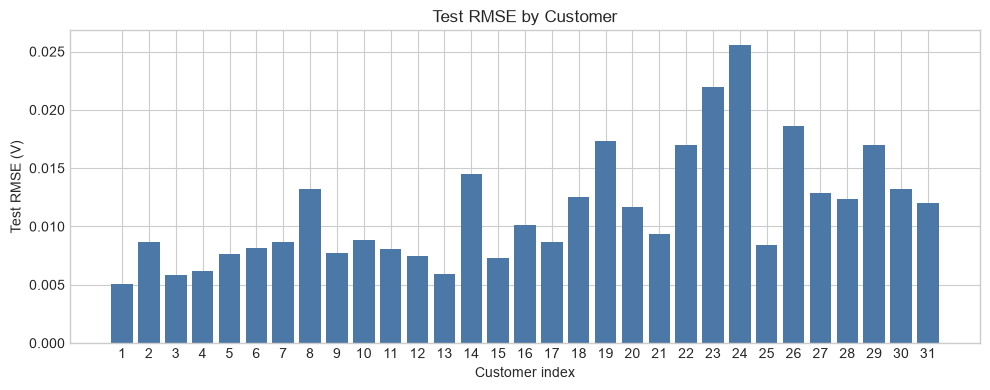

In [23]:
plt.figure(figsize=(10, 4))
plt.bar(np.arange(1, C + 1), per_customer_rmse, color="#4C78A8")
plt.xlabel("Customer index")
plt.ylabel("Test RMSE (V)")
plt.title("Test RMSE by Customer")
plt.xticks(np.arange(1, C + 1))
plt.tight_layout()
plt.show()


#### 2.6.3 Compare measured and estimated voltage profiles

The worst, median and best customers are selected using per-customer test RMSE. Their measured and estimated voltage traces show whether the model follows the correct temporal pattern as well as the average error magnitude.


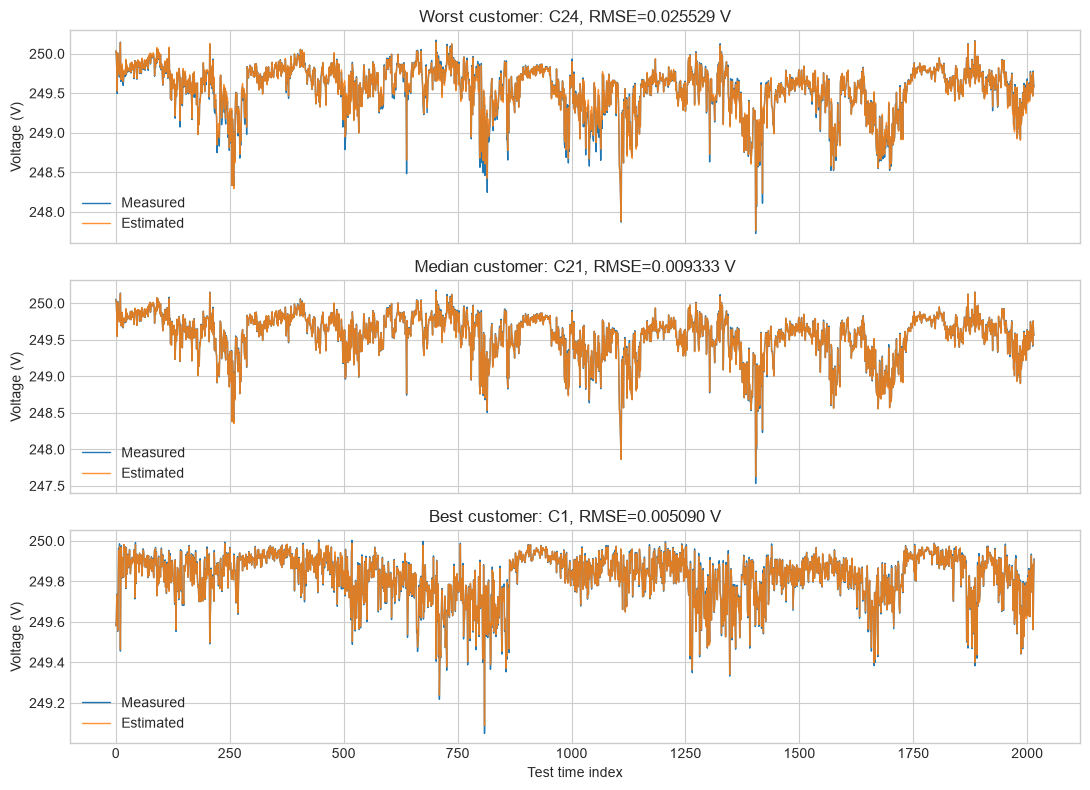

In [24]:
customer_order = np.argsort(per_customer_rmse)
representative_customers = [
    ("Worst", int(customer_order[-1])),
    ("Median", int(customer_order[len(customer_order) // 2])),
    ("Best", int(customer_order[0])),
]
time_index = np.arange(len(V_te))

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for axis, (label, customer) in zip(axes, representative_customers):
    axis.plot(time_index, V_te[:, customer], label="Measured", linewidth=1.0)
    axis.plot(
        time_index,
        Vte_estimated[:, customer],
        label="Estimated",
        linewidth=1.0,
        alpha=0.85,
    )
    axis.set_ylabel("Voltage (V)")
    axis.set_title(
        f"{label} customer: C{customer + 1}, "
        f"RMSE={per_customer_rmse[customer]:.6f} V"
    )
    axis.legend(loc="best")
axes[-1].set_xlabel("Test time index")
fig.tight_layout()
plt.show()


The reference run selected seed 1 and reported an overall test RMSE of approximately 0.01235 V and MAE of approximately 0.00747 V. Small numerical differences can occur across hardware and software versions. These metrics describe only this fixed feeder, customer ordering and held-out period; they do not establish accuracy for another network or changed topology.


## 3. Exercises

First, read all exercises so you understand their purpose.

At the very end of this notebook in **4. Simulation Workspace**, you can place the code relevant to each exercise and run it together. Keep the held-out test period separate until your model settings have been fixed.


### **Exercise: Investigating an LV Voltage-Estimation Model**

In this exercise, you will use the same LV dataset and modify selected parts of the model-development workflow.

**E.1:** Recreate the three blocked folds and identify the validation time-index range used by each fold. Explain why random K-fold validation would be inappropriate for this chronological dataset. Also inspect whether any validation values fall outside `[0,1]` after scaling and explain why this is not automatically a data error.

**E.2:** Compare `tanh` and `relu` using hidden-layer sizes of `3|C|` and `5|C|`. Keep learning rate `1e-3`, weight decay `1e-5`, batch size 72 and epochs 300 so the exercise remains manageable. Rank the four configurations using mean three-fold validation RMSE. Do not use the test period.

**E.3:** Use the best configuration from E.2 to train three random seeds on the complete training window. Select the seed with the lowest training RMSE, evaluate it once on the held-out test period and answer:

- How does its overall test RMSE compare with the reference model?
- Which customer has the highest RMSE?
- Do the measured and estimated traces show a systematic error or isolated deviations?


In [25]:
# Suggested starting point for E.1
# exercise_folds = blocked_kfold_indices(len(PQ_tr), k=3)
# for fold_number, (training_indices, validation_indices) in enumerate(exercise_folds, 1):
#     print(
#         fold_number,
#         len(training_indices),
#         len(validation_indices),
#         validation_indices[0],
#         validation_indices[-1],
#     )


In [26]:
# Suggested starting point for E.2
# EXERCISE_SPACE = {
#     "hidden_multiplier": [3, 5],
#     "activation": ["tanh", "relu"],
#     "lr": [1e-3],
#     "weight_decay": [1e-5],
#     "batch_size": [72],
#     "epochs": [300],
# }
# exercise_results = run_grid_search(
#     PQ_tr,
#     V_tr,
#     C,
#     search_space=EXERCISE_SPACE,
# )
# display(exercise_results.round(6))


For E.3, reuse the complete-training scalers and final-training logic from Section 2.5.3, but store the exercise model and results under new variable names so the reference result remains available for comparison.


## 4. Simulation Workspace


In [27]:
# Assemble and run the code required for Exercises E.1–E.3 here.
